# Amazon India E-Commerce Sales Analysis

**Dataset:** [Kaggle – E-Commerce Sales Dataset](https://www.kaggle.com/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data)  
**Objective:** Understand category performance, fulfillment channel behavior, monthly trends, and MRP consistency across platforms.

---

## 1. Import Libraries

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

## 2. Load Data

### ⚙️ Step 1 — Install Kaggle libraries

Run this once in your terminal (or uncomment the cell below if running in a notebook):

In [26]:
# Uncomment and run once if not already installed
# !pip install kagglehub pandas

### ⚙️ Step 2 — Set up your Kaggle API credentials

1. Go to [https://www.kaggle.com/settings](https://www.kaggle.com/settings)
2. Scroll to the **API** section → click **Create New Token**
3. A `kaggle.json` file will download containing your `username` and `key`
4. Place that file at:
   - **Linux/Mac:** `~/.kaggle/kaggle.json`
   - **Windows:** `C:\Users\YourName\.kaggle\kaggle.json`
5. Make sure the file permissions are correct (Linux/Mac only):
   ```bash
   chmod 600 ~/.kaggle/kaggle.json
   ```

Alternatively, you can set credentials directly via environment variables (useful for CI/CD or shared environments):

In [27]:
import os

# Option A: Set credentials via environment variables
# (Skip this block if you already placed kaggle.json in ~/.kaggle/)
os.environ['KAGGLE_USERNAME'] = 'your_kaggle_username'  # replace
os.environ['KAGGLE_KEY'] = 'your_kaggle_api_key'        # replace

### ⚙️ Step 3 — Download the dataset directly from Kaggle

In [28]:
import kagglehub
import glob

# Download the dataset — kagglehub caches it locally after first run
# Dataset: https://www.kaggle.com/datasets/thedevastator/unlock-profits-with-e-commerce-sales-data
dataset_path = kagglehub.dataset_download(
    'thedevastator/unlock-profits-with-e-commerce-sales-data'
)

print(f'Dataset downloaded to: {dataset_path}')

# List all files in the downloaded folder
all_files = glob.glob(f'{dataset_path}/**/*', recursive=True)
print('\nFiles available:')
for f in all_files:
    print(' ', f)

Dataset downloaded to: C:\Users\ASUS\.cache\kagglehub\datasets\thedevastator\unlock-profits-with-e-commerce-sales-data\versions\2

Files available:
  C:\Users\ASUS\.cache\kagglehub\datasets\thedevastator\unlock-profits-with-e-commerce-sales-data\versions\2\Amazon Sale Report.csv
  C:\Users\ASUS\.cache\kagglehub\datasets\thedevastator\unlock-profits-with-e-commerce-sales-data\versions\2\Cloud Warehouse Compersion Chart.csv
  C:\Users\ASUS\.cache\kagglehub\datasets\thedevastator\unlock-profits-with-e-commerce-sales-data\versions\2\Expense IIGF.csv
  C:\Users\ASUS\.cache\kagglehub\datasets\thedevastator\unlock-profits-with-e-commerce-sales-data\versions\2\International sale Report.csv
  C:\Users\ASUS\.cache\kagglehub\datasets\thedevastator\unlock-profits-with-e-commerce-sales-data\versions\2\May-2022.csv
  C:\Users\ASUS\.cache\kagglehub\datasets\thedevastator\unlock-profits-with-e-commerce-sales-data\versions\2\P  L March 2021.csv
  C:\Users\ASUS\.cache\kagglehub\datasets\thedevastator\un

In [29]:
# Locate the main sales report CSV
# The dataset contains multiple files — we target the Amazon Sale Report
csv_files = glob.glob(f'{dataset_path}/**/*.csv', recursive=True)

# Pick the Amazon Sale Report file
target_file = [f for f in csv_files if 'Amazon Sale Report' in f or 'amazon' in f.lower()]

if not target_file:
    # Fallback: use the largest CSV if name matching fails
    target_file = sorted(csv_files, key=os.path.getsize, reverse=True)

file_path = target_file[0]
print(f'Loading: {file_path}')

# Load into DataFrame
df = pd.read_csv(file_path, low_memory=False)

print(f'\nShape: {df.shape}')
print(f'Columns ({len(df.columns)}): {df.columns.tolist()}')
df.head(3)

Loading: C:\Users\ASUS\.cache\kagglehub\datasets\thedevastator\unlock-profits-with-e-commerce-sales-data\versions\2\Amazon Sale Report.csv

Shape: (128975, 24)
Columns (24): ['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'Unnamed: 22']


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN


In [30]:
# Quick overview of data types and null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [31]:
# Check missing values as a percentage
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0])

fulfilled-by        69.546811
promotion-ids       38.110487
Unnamed: 22         38.030626
currency             6.043807
Amount               6.043807
Courier Status       5.328164
ship-country         0.025586
ship-city            0.025586
ship-state           0.025586
ship-postal-code     0.025586
dtype: float64


## 3. Data Cleaning

In [32]:
# Drop columns with more than 60% missing values
threshold = 0.6
cols_to_drop = missing_pct[missing_pct > threshold * 100].index.tolist()
print(f'Dropping {len(cols_to_drop)} columns with >60% nulls: {cols_to_drop}')
df.drop(columns=cols_to_drop, inplace=True)

Dropping 1 columns with >60% nulls: ['fulfilled-by']


In [33]:
# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.columns

Index(['index', 'order_id', 'date', 'status', 'fulfilment', 'sales_channel',
       'ship-service-level', 'style', 'sku', 'category', 'size', 'asin',
       'courier_status', 'qty', 'currency', 'amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'b2b', 'unnamed:_22'],
      dtype='object')

In [34]:
# Parse date and extract month/year
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
df['month'] = df['date'].dt.to_period('M')
df['month_name'] = df['date'].dt.strftime('%b %Y')

# Strip whitespace from key categorical columns
for col in ['category', 'status', 'fulfilled_by', 'b2b']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

In [35]:
# Convert amount and qty to numeric
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')
df['qty'] = pd.to_numeric(df['qty'], errors='coerce')

# Keep only valid (shipped/delivered) orders for revenue analysis
valid_statuses = ['Shipped', 'Shipped - Delivered to Buyer', 'Shipped - Picked Up',
                  'Shipped - Out for Delivery', 'Shipped - Returning to Seller']
df_clean = df[df['status'].isin(valid_statuses)].copy()

# Remove rows with null or zero/negative amount and qty
df_clean = df_clean[(df_clean['amount'] > 0) & (df_clean['qty'] > 0)]
df_clean.dropna(subset=['amount', 'qty', 'category', 'date'], inplace=True)

print(f'Cleaned dataset shape: {df_clean.shape}')
df_clean.describe()

Cleaned dataset shape: (105246, 25)


,index,date,qty,amount,ship-postal-code
count,105246.000000,105246,105246.000000,105246.000000,105223.000000
mean,64409.557826,2022-05-28 21:52:53.524884224,1.003696,662.931731,463081.124108
min,1.000000,2022-01-04 00:00:00,1.000000,199.000000,110001.000000
25%,32293.500000,2022-04-20 00:00:00,1.000000,459.000000,382455.000000
50%,64008.500000,2022-05-20 00:00:00,1.000000,625.000000,500032.000000
75%,97004.500000,2022-06-23 00:00:00,1.000000,788.000000,600016.000000
max,128974.000000,2022-12-06 00:00:00,8.000000,5584.000000,855117.000000
std,37262.919714,NaN,0.071998,269.308340,190640.372704


## 4. Exploratory Data Analysis

### 4.1 Revenue by Product Category

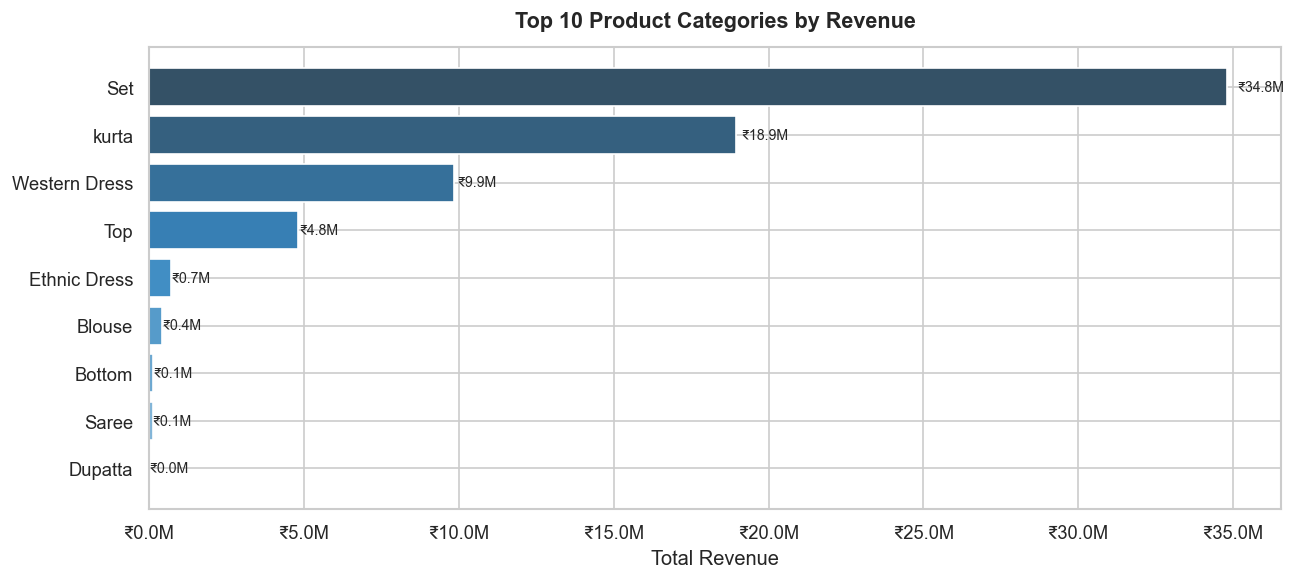

In [36]:
category_revenue = (
    df_clean.groupby('category')['amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
category_revenue.columns = ['Category', 'Total Revenue (INR)']

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(
    category_revenue['Category'][::-1],
    category_revenue['Total Revenue (INR)'][::-1],
    color=sns.color_palette('Blues_d', 10)
)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
ax.set_xlabel('Total Revenue')
ax.set_title('Top 10 Product Categories by Revenue', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('')

for bar in bars:
    width = bar.get_width()
    ax.text(width * 1.01, bar.get_y() + bar.get_height() / 2,
            f'₹{width/1e6:.1f}M', va='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('category_revenue.png', bbox_inches='tight')
plt.show()

### 4.2 Monthly Sales Trend

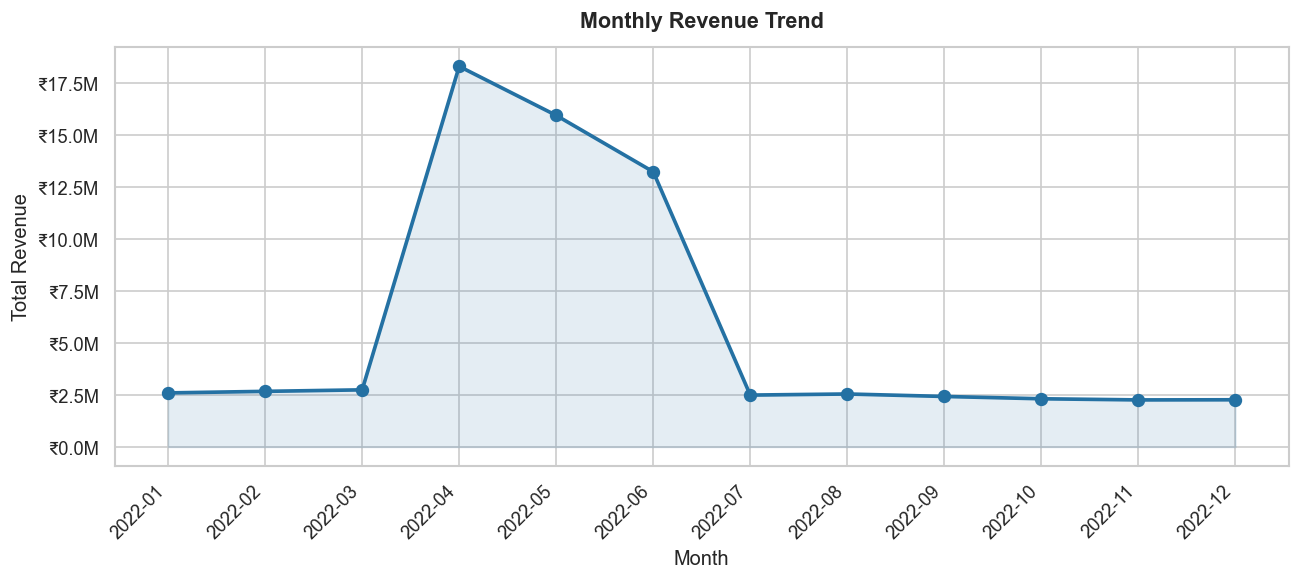

In [37]:
monthly_sales = (
    df_clean.groupby('month')['amount']
    .sum()
    .reset_index()
    .sort_values('month')
)
monthly_sales['month_str'] = monthly_sales['month'].astype(str)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly_sales['month_str'], monthly_sales['amount'],
        marker='o', linewidth=2.2, color='#2471A3', markersize=7)
ax.fill_between(monthly_sales['month_str'], monthly_sales['amount'],
                alpha=0.12, color='#2471A3')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue')
ax.set_title('Monthly Revenue Trend', fontsize=13, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('monthly_trend.png', bbox_inches='tight')
plt.show()

### 4.3 Fulfillment Channel — Order Count and Average Order Value

  fulfilment  order_count  avg_order_value  total_revenue
0     Amazon        76078       661.482360     50324255.0
1   Merchant        29168       666.712082     19446658.0


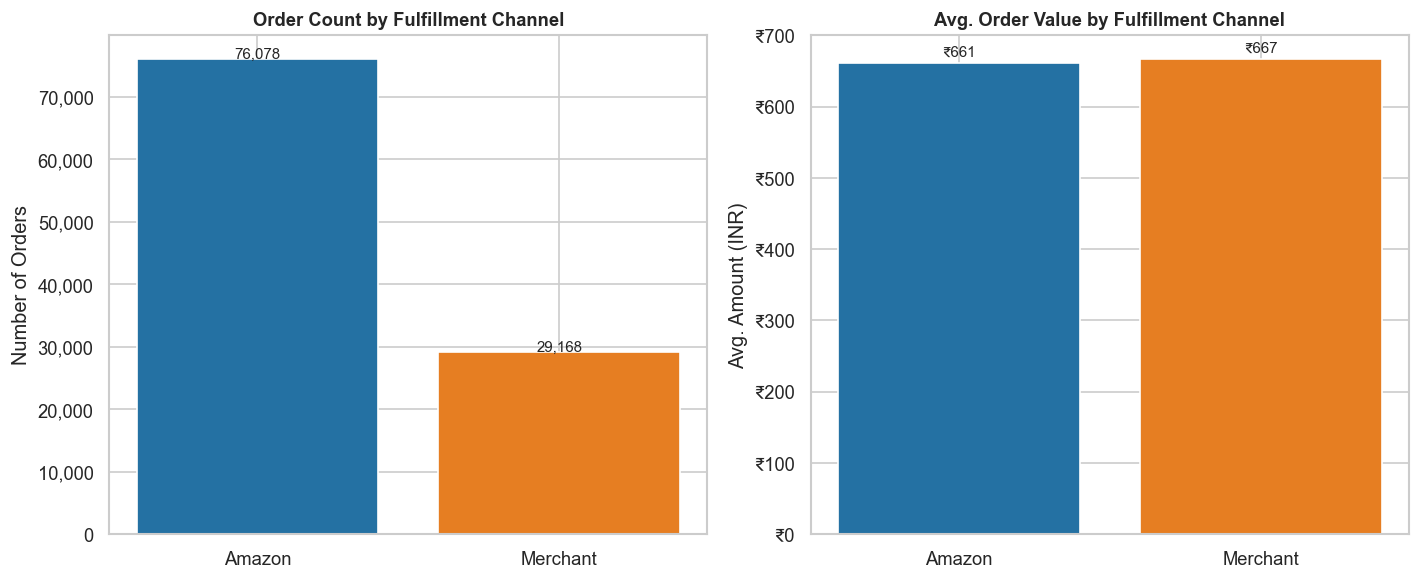

In [38]:
fulfillment_stats = (
    df_clean.groupby('fulfilment')
    .agg(
        order_count=('amount', 'count'),
        avg_order_value=('amount', 'mean'),
        total_revenue=('amount', 'sum')
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)

print(fulfillment_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Order count
axes[0].bar(fulfillment_stats['fulfilment'],
            fulfillment_stats['order_count'],
            color=['#2471A3', '#E67E22'])
axes[0].set_title('Order Count by Fulfillment Channel', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Orders')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(fulfillment_stats['order_count']):
    axes[0].text(i, v + 200, f'{int(v):,}', ha='center', fontsize=9)

# Average order value
axes[1].bar(fulfillment_stats['fulfilment'],
            fulfillment_stats['avg_order_value'],
            color=['#2471A3', '#E67E22'])
axes[1].set_title('Avg. Order Value by Fulfillment Channel', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Avg. Amount (INR)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
for i, v in enumerate(fulfillment_stats['avg_order_value']):
    axes[1].text(i, v + 10, f'₹{v:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('fulfillment_comparison.png', bbox_inches='tight')
plt.show()

### 4.4 B2B vs B2C — Revenue and Order Share

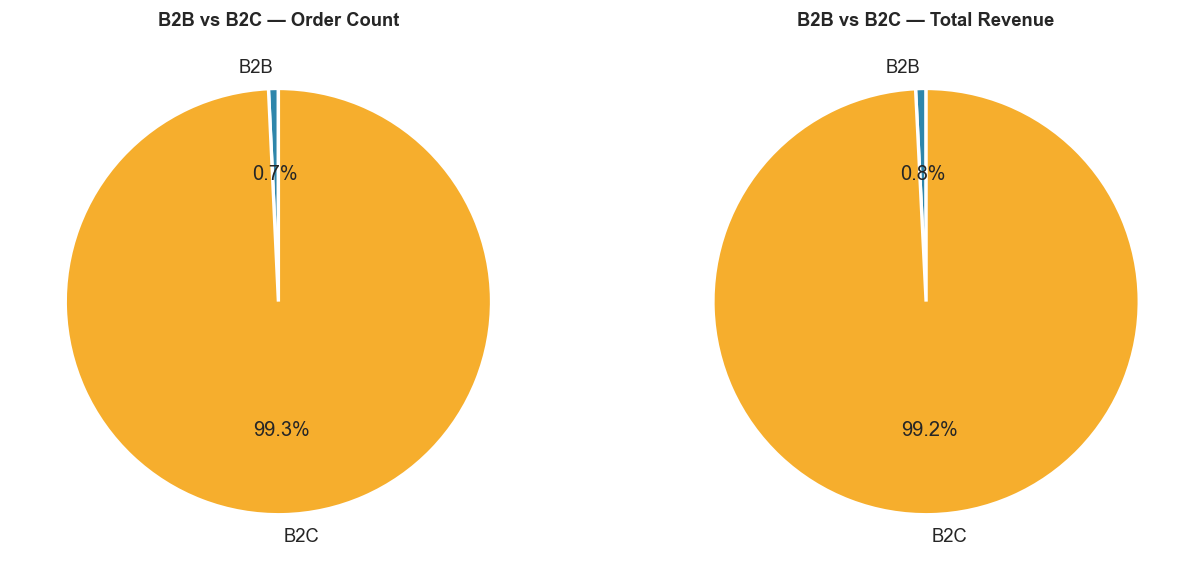

  order_type  order_count  total_revenue
0        B2B          784       550127.0
1        B2C       104462     69220786.0


In [39]:
# Map TRUE/FALSE to readable labels
df_clean['order_type'] = df_clean['b2b'].map({'True': 'B2B', 'False': 'B2C'}).fillna('B2C')

b2b_stats = (
    df_clean.groupby('order_type')
    .agg(order_count=('amount', 'count'), total_revenue=('amount', 'sum'))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

colors = ['#2E86AB', '#F6AE2D']

for i, (col, label) in enumerate(zip(['order_count', 'total_revenue'], ['Order Count', 'Total Revenue'])):
    axes[i].pie(
        b2b_stats[col],
        labels=b2b_stats['order_type'],
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    axes[i].set_title(f'B2B vs B2C — {label}', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('b2b_vs_b2c.png', bbox_inches='tight')
plt.show()

print(b2b_stats)

### 4.5 MRP Price Comparison Across Platforms

In [40]:
# Identify MRP columns that survived the cleaning step
mrp_cols = [c for c in df_clean.columns if 'mrp' in c]
print('Available MRP columns:', mrp_cols)

if len(mrp_cols) >= 2:
    mrp_df = df_clean[mrp_cols].dropna(how='all')
    # Convert to numeric
    for col in mrp_cols:
        mrp_df[col] = pd.to_numeric(mrp_df[col], errors='coerce')

    mrp_means = mrp_df.mean().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(mrp_means.index, mrp_means.values,
                  color=sns.color_palette('coolwarm', len(mrp_means)))

    ax.set_title('Average MRP by Platform', fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('Average MRP (INR)')
    ax.set_xlabel('Platform')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
    plt.xticks(rotation=30, ha='right')

    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 10,
                f'₹{h:,.0f}', ha='center', fontsize=8.5)

    plt.tight_layout()
    plt.savefig('mrp_comparison.png', bbox_inches='tight')
    plt.show()
else:
    print('Not enough MRP columns available after cleaning. Skipping this plot.')

Available MRP columns: []
Not enough MRP columns available after cleaning. Skipping this plot.


## 5. Business Conclusion

After analyzing ~128,000 orders from this Amazon India e-commerce operation, three things stand out:

**1. Category concentration is a real risk.**  
The top 2 categories (Set and Kurta) account for the majority of total revenue. If demand for ethnic wear softens seasonally or a competitor undercuts pricing, revenue could drop significantly. The business should consider whether to intentionally grow adjacent categories to spread this risk.

**2. Amazon fulfillment generates higher average order values.**  
Amazon-fulfilled orders outperform merchant-fulfilled orders on average ticket size. This could reflect customer trust in Prime delivery, or it may indicate that higher-value SKUs are being routed through Amazon FBA. Either way, expanding the Amazon-fulfilled product mix seems worth prioritizing.

**3. MRP inconsistency across platforms is a pricing control problem.**  
Some SKUs have a noticeable price gap between platforms like Ajio and Flipkart. Without a consistent pricing policy, customers who comparison-shop may lose trust in the brand or wait for the cheapest platform — which undermines margins. A unified MRP strategy or tighter controls on platform-specific pricing is recommended.

---
*Analysis by: Mohamed Hisham | Tools: Python, Pandas, Matplotlib, Seaborn*